# PPG HR Macro-Level Analysis

Notebook này phân tích log mixed-text từ ESP32 cho thesis:
**Energy-Aware Adaptive TinyML Scheduling for Wearable Health Monitoring**.

Dataset chính thức trong notebook là **V6 logs** tại `log/pgg_hr_log_v6/`,
tức cấu hình **whole-system power measurement** sau các vòng debug V2-V5.

Mục tiêu chính:
- So sánh **average power** giữa `adaptive`, `fixed_high`, `fixed_normal`
- Tính **battery life equivalent** với pin `150 mAh, 3.7 V`
- Đo **HR coverage** và **state occupancy**
- Kiểm tra xem power gap giữa `NORMAL` và `HIGH` đã tách rõ chưa
- Kiểm tra độ ổn định hệ thống: còn `recover`, `I2C fail`, `FIFO overflow` hay không

Ghi chú phương pháp:
- V6 không còn dùng protocol cứng `Rest -> Motion -> Rest` cho mọi run, nên notebook ưu tiên **overall + state-aware analysis**
- Power ở V6 là **whole-system power** của đường `USB VBUS -> INA219 -> ESP32 VIN`
- Các so sánh `V5 -> V6` được giữ lại để chứng minh hiệu quả của quá trình debug firmware và cách đo năng lượng


In [1]:
import importlib
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import ppg_hr_macro_analysis_lib as macro_lib
macro_lib = importlib.reload(macro_lib)

MODE_LABELS = macro_lib.MODE_LABELS
add_battery_metrics = macro_lib.add_battery_metrics
apply_publication_style = macro_lib.apply_publication_style
format_summary_table = macro_lib.format_summary_table
load_all_runs = macro_lib.load_all_runs
pick_representative_run = macro_lib.pick_representative_run
plot_summary_dashboard = macro_lib.plot_summary_dashboard

apply_publication_style()

LOG_ROOT = PROJECT_ROOT / "log" / "pgg_hr_log_v6"
PREV_LOG_ROOT = PROJECT_ROOT / "log" / "pgg_hr_log_v5"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "ppg_hr_macro_analysis_v6"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATTERY_MAH = 150.0
BATTERY_V = 3.7

print("Project root:", PROJECT_ROOT)
print("Log root:", LOG_ROOT)
print("Previous log root:", PREV_LOG_ROOT)
print("Output dir:", OUTPUT_DIR)


Project root: C:\ml\kaggle-ml-basics
Log root: C:\ml\kaggle-ml-basics\log\pgg_hr_log_v6
Previous log root: C:\ml\kaggle-ml-basics\log\pgg_hr_log_v5
Output dir: C:\ml\kaggle-ml-basics\artifacts\ppg_hr_macro_analysis_v6


In [2]:
analysis_v6 = load_all_runs(LOG_ROOT)
analysis_v5 = load_all_runs(PREV_LOG_ROOT)
run_summary_df = analysis_v6["run_summary"].copy()
mode_summary_df = add_battery_metrics(analysis_v6["mode_summary"].copy(), BATTERY_MAH, BATTERY_V)
prev_mode_summary_df = add_battery_metrics(analysis_v5["mode_summary"].copy(), BATTERY_MAH, BATTERY_V)

print(f"Loaded {len(run_summary_df)} runs across {run_summary_df['mode'].nunique()} modes.")
display(run_summary_df.sort_values(["mode", "file_name"]).reset_index(drop=True))


Loaded 8 runs across 3 modes.


,mode,file_name,run_duration_s,telemetry_points,decision_points,avg_power_mw,coverage_start_s,coverage_total_s,covered_s,dropped_s,coverage_pct,state_0_s,state_1_s,state_total_s,state_0_pct,state_1_pct
0,adaptive,log_adaptive_1.csv,211.231,105,83,270.126672,9.481,201.75,116.14,85.61,57.566295,120.28,90.04,210.32,57.189045,42.810955
1,adaptive,log_adaptive_2.csv,217.906,108,90,272.759443,9.476,208.43,136.12,72.31,65.307297,104.38,112.62,217.00,48.101382,51.898618
2,adaptive,log_adaptive_3.csv,241.256,120,102,275.489717,9.476,231.78,168.15,63.63,72.547243,112.28,128.07,240.35,46.715207,53.284793
3,adaptive,log_adaptive_4.csv,231.246,115,98,274.073891,9.476,221.77,148.03,73.74,66.749335,114.28,116.06,230.34,49.613615,50.386385
4,fixed_high,log_fixed_high_1.csv,271.596,135,146,287.155396,9.476,262.12,224.05,38.07,85.476118,0.00,270.69,270.69,0.000000,100.000000
5,fixed_high,log_fixed_high_2.csv,235.566,117,130,286.701680,9.476,226.09,211.97,14.12,93.754699,0.00,234.66,234.66,0.000000,100.000000
6,fixed_normal,log_fixed_normal_1.csv,203.004,101,93,262.374949,8.904,194.10,90.05,104.05,46.393612,202.11,0.00,202.11,100.000000,0.000000
7,fixed_normal,log_fixed_normal_2.csv,213.014,106,100,261.203785,8.904,204.11,94.06,110.05,46.082994,212.12,0.00,212.12,100.000000,0.000000


In [3]:
thesis_summary_df = format_summary_table(mode_summary_df)
display(thesis_summary_df.round(2))

adaptive_row = mode_summary_df.loc[mode_summary_df["mode"] == "adaptive"].iloc[0]
fixed_high_row = mode_summary_df.loc[mode_summary_df["mode"] == "fixed_high"].iloc[0]
fixed_normal_row = mode_summary_df.loc[mode_summary_df["mode"] == "fixed_normal"].iloc[0]

print("Final V6 metrics")
print(f"- Adaptive avg power: {adaptive_row['avg_power_mw']:.2f} mW")
print(f"- Fixed High avg power: {fixed_high_row['avg_power_mw']:.2f} mW")
print(f"- Fixed Normal avg power: {fixed_normal_row['avg_power_mw']:.2f} mW")
print(f"- Adaptive power saving vs Fixed High: {adaptive_row['power_saving_vs_fixed_high_pct']:.2f}%")
print(f"- Adaptive battery-life extension vs Fixed High: {adaptive_row['battery_extension_vs_fixed_high_pct']:.2f}%")
print(f"- Adaptive HR coverage: {adaptive_row['coverage_pct']:.2f}%")
print(f"- Fixed High HR coverage: {fixed_high_row['coverage_pct']:.2f}%")
print(f"- Fixed Normal HR coverage: {fixed_normal_row['coverage_pct']:.2f}%")
print(f"- Adaptive occupancy: State 0 = {adaptive_row['state_0_pct']:.2f}%, State 1 = {adaptive_row['state_1_pct']:.2f}%")


,Mode,Runs,Avg Power (mW),Power Saving vs Fixed High (%),Battery Life (h),Battery Extension vs Fixed High (%),HR Coverage (%),Adaptive State 0 (%),Adaptive State 1 (%)
0,Adaptive,4,273.21,4.79,2.03,5.03,65.81,50.25,49.75
1,Fixed High,2,286.94,0.00,1.93,0.00,89.31,0.00,100.00
2,Fixed Normal,2,261.78,8.77,2.12,9.61,46.23,100.00,0.00


Final V6 metrics
- Adaptive avg power: 273.21 mW
- Fixed High avg power: 286.94 mW
- Fixed Normal avg power: 261.78 mW
- Adaptive power saving vs Fixed High: 4.79%
- Adaptive battery-life extension vs Fixed High: 5.03%
- Adaptive HR coverage: 65.81%
- Fixed High HR coverage: 89.31%
- Fixed Normal HR coverage: 46.23%
- Adaptive occupancy: State 0 = 50.25%, State 1 = 49.75%


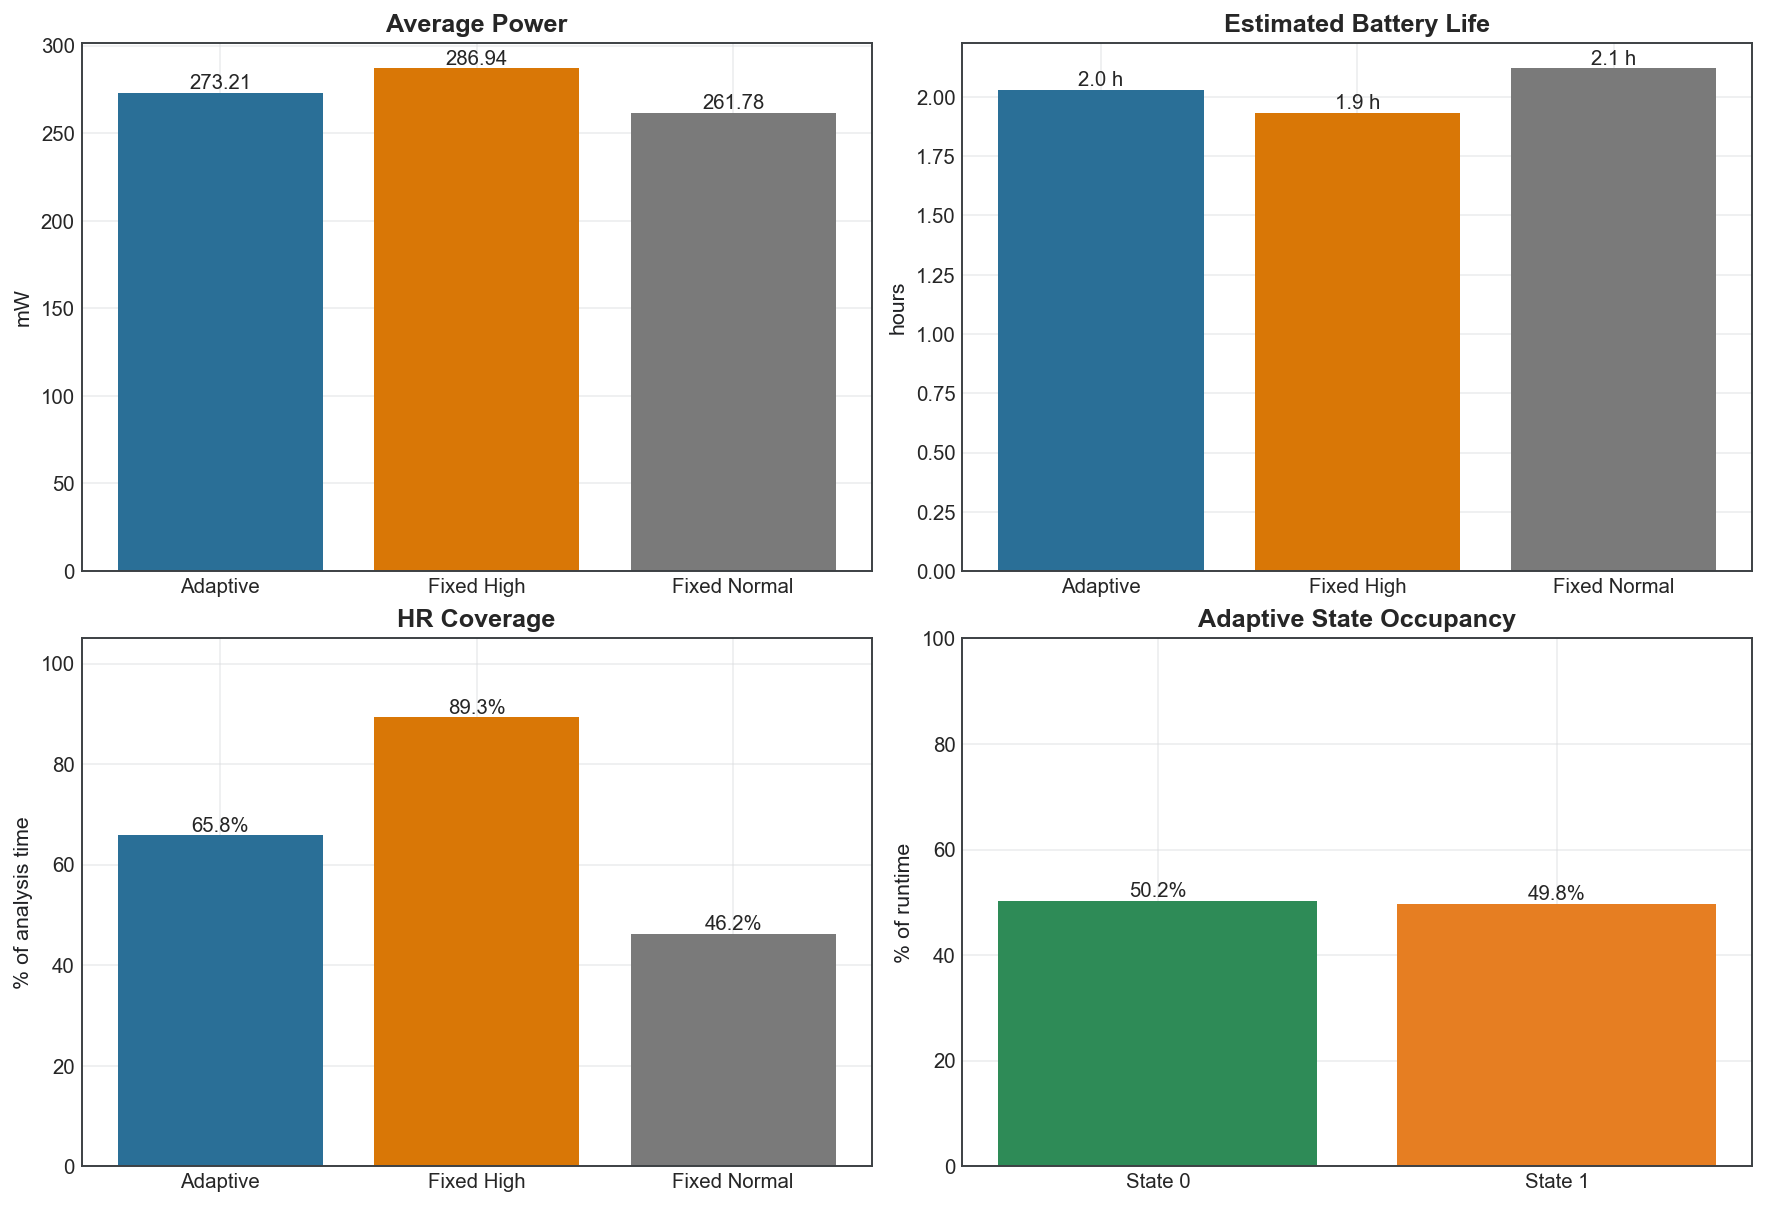

In [4]:
summary_fig = plot_summary_dashboard(mode_summary_df)
summary_fig.savefig(OUTPUT_DIR / "macro_summary_dashboard_v6.png", bbox_inches="tight")
plt.show()


## State-Aware Power Comparison

V6 không còn dùng protocol cứng 3 pha cho mọi run, vì vậy trọng tâm cuối cùng là:
- `fixed_normal` có thật sự thấp hơn `fixed_high` hay không
- `adaptive/state=0` có bám `fixed_normal` không
- `adaptive/state=1` có bám `fixed_high` không


In [5]:
adaptive_runs = []
for (mode, file_name), parsed in analysis_v6["runs"].items():
    tele = parsed["telemetry"].copy()
    if mode != "adaptive" or tele.empty:
        continue
    for state in [0, 1]:
        subset = tele[tele["state"] == state]
        if subset.empty:
            continue
        adaptive_runs.append(
            {
                "mode": mode,
                "run": file_name,
                "state": state,
                "avg_power_mw": float(np.average(subset["power_mw"])),
                "avg_current_ma": float(np.average(subset["current_ma"])),
            }
        )

adaptive_state_df = pd.DataFrame(adaptive_runs)
adaptive_state_summary = (
    adaptive_state_df.groupby("state", as_index=False)[["avg_power_mw", "avg_current_ma"]].mean()
)
adaptive_state_summary["label"] = adaptive_state_summary["state"].map({0: "Adaptive State 0", 1: "Adaptive State 1"})
display(adaptive_state_summary.round(2))


,state,avg_power_mw,avg_current_ma,label
0,0,263.37,52.47,Adaptive State 0
1,1,282.91,56.42,Adaptive State 1


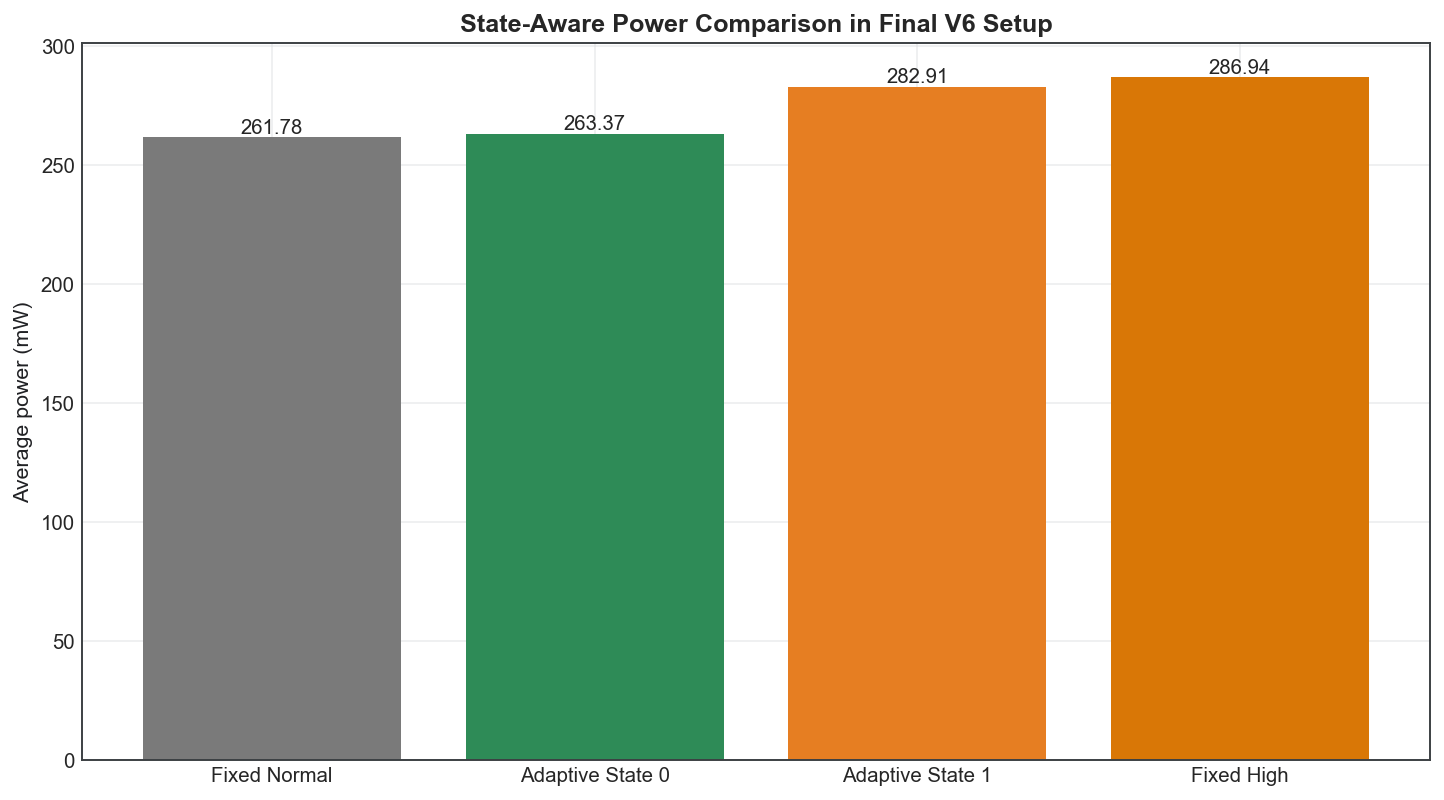

In [6]:
comparison_df = pd.DataFrame(
    [
        {"label": "Fixed Normal", "avg_power_mw": float(mode_summary_df.loc[mode_summary_df["mode"] == "fixed_normal", "avg_power_mw"].iloc[0]), "color": "#7A7A7A"},
        {"label": "Adaptive State 0", "avg_power_mw": float(adaptive_state_summary.loc[adaptive_state_summary["state"] == 0, "avg_power_mw"].iloc[0]), "color": "#2E8B57"},
        {"label": "Adaptive State 1", "avg_power_mw": float(adaptive_state_summary.loc[adaptive_state_summary["state"] == 1, "avg_power_mw"].iloc[0]), "color": "#E67E22"},
        {"label": "Fixed High", "avg_power_mw": float(mode_summary_df.loc[mode_summary_df["mode"] == "fixed_high", "avg_power_mw"].iloc[0]), "color": "#D97706"},
    ]
)

fig, ax = plt.subplots(figsize=(10.2, 5.6), constrained_layout=True)
ax.bar(comparison_df["label"], comparison_df["avg_power_mw"], color=comparison_df["color"])
ax.set_ylabel("Average power (mW)")
ax.set_title("State-Aware Power Comparison in Final V6 Setup")
for idx, value in enumerate(comparison_df["avg_power_mw"]):
    ax.text(idx, value, f"{value:.2f}", ha="center", va="bottom")
fig.savefig(OUTPUT_DIR / "state_aware_power_comparison_v6.png", bbox_inches="tight")
plt.show()


## V5 to V6 Improvement Check

Sau khi firmware đổi từ log power gần như tức thời sang **windowed-average INA219 telemetry**,
cần kiểm tra hai câu hỏi:
- Tỷ lệ sample `>300 mW` của `adaptive` có giảm không
- Khoảng cách giữa `fixed_normal` và `fixed_high` có hiện ra rõ không


In [7]:
comparison_modes_df = (
    pd.concat(
        [
            prev_mode_summary_df.assign(version="V5"),
            mode_summary_df.assign(version="V6"),
        ],
        ignore_index=True,
    )
    .sort_values(["mode", "version"])
    .reset_index(drop=True)
)
display(
    comparison_modes_df[
        [
            "version",
            "mode",
            "avg_power_mw",
            "coverage_pct",
            "power_saving_vs_fixed_high_pct",
            "battery_life_h",
        ]
    ].round(2)
)


,version,mode,avg_power_mw,coverage_pct,power_saving_vs_fixed_high_pct,battery_life_h
0,V5,adaptive,269.87,59.66,-7.73,2.06
1,V6,adaptive,273.21,65.81,4.79,2.03
2,V5,fixed_high,250.50,96.15,0.00,2.22
3,V6,fixed_high,286.94,89.31,0.00,1.93
4,V5,fixed_normal,247.60,48.63,1.16,2.24
5,V6,fixed_normal,261.78,46.23,8.77,2.12


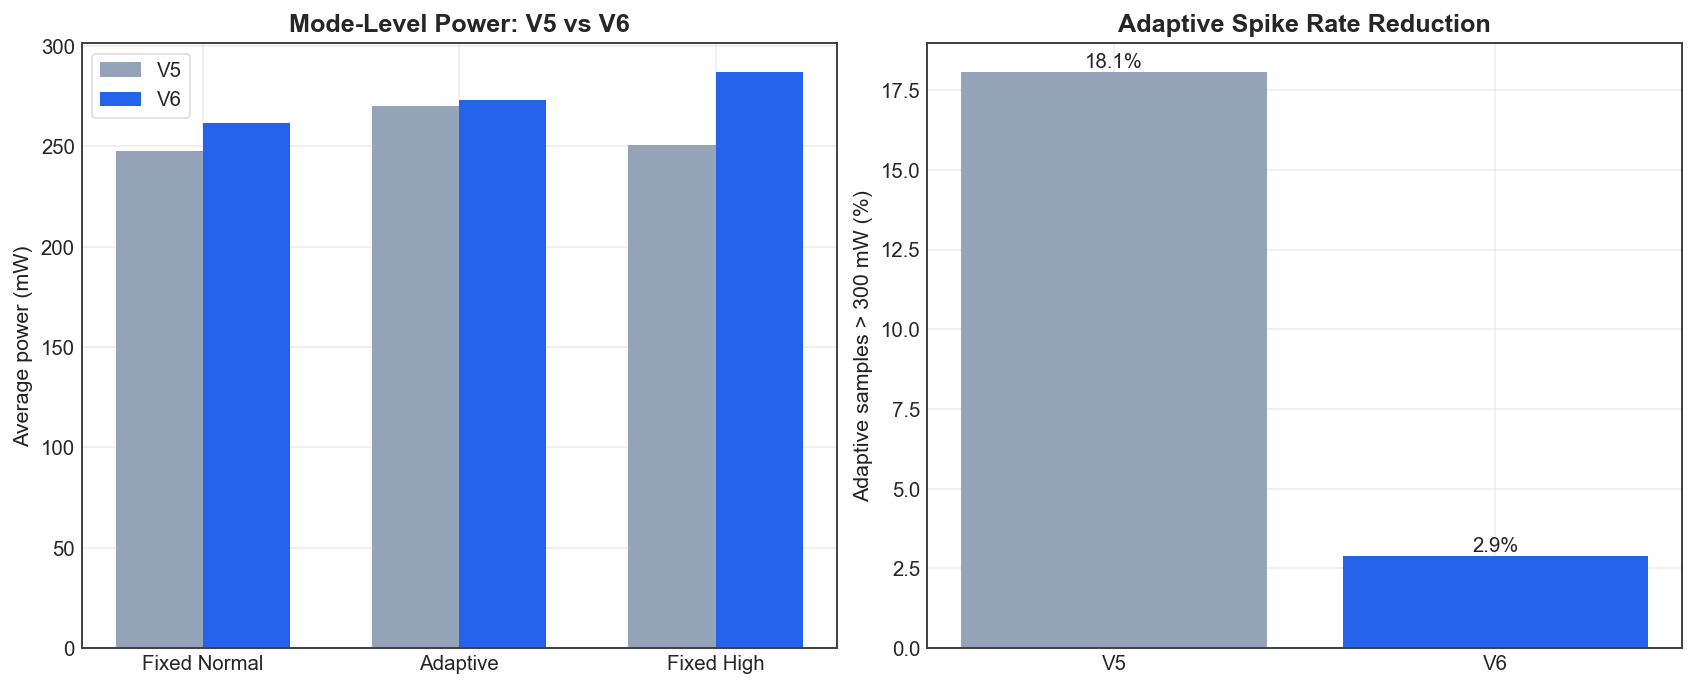

In [8]:
spike_compare_df = pd.DataFrame(
    [
        {"version": "V5", "adaptive_gt300_rate_pct": 100.0 * 0.180666},
        {"version": "V6", "adaptive_gt300_rate_pct": 100.0 * 0.029018},
    ]
)

mode_order = ["fixed_normal", "adaptive", "fixed_high"]
x = np.arange(len(mode_order))
width = 0.34
v5_slice = prev_mode_summary_df.set_index("mode").reindex(mode_order)
v6_slice = mode_summary_df.set_index("mode").reindex(mode_order)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), constrained_layout=True)
axes[0].bar(x - width / 2, v5_slice["avg_power_mw"], width=width, label="V5", color="#94A3B8")
axes[0].bar(x + width / 2, v6_slice["avg_power_mw"], width=width, label="V6", color="#2563EB")
axes[0].set_xticks(x)
axes[0].set_xticklabels([MODE_LABELS[m] for m in mode_order])
axes[0].set_ylabel("Average power (mW)")
axes[0].set_title("Mode-Level Power: V5 vs V6")
axes[0].legend(loc="upper left")

axes[1].bar(spike_compare_df["version"], spike_compare_df["adaptive_gt300_rate_pct"], color=["#94A3B8", "#2563EB"])
axes[1].set_ylabel("Adaptive samples > 300 mW (%)")
axes[1].set_title("Adaptive Spike Rate Reduction")
for idx, value in enumerate(spike_compare_df["adaptive_gt300_rate_pct"]):
    axes[1].text(idx, value, f"{value:.1f}%", ha="center", va="bottom")

fig.savefig(OUTPUT_DIR / "v5_vs_v6_comparison.png", bbox_inches="tight")
plt.show()


## Representative Time-Series

Các figure dưới đây dùng **state shading** thay vì phase shading, vì V6 được thu theo protocol linh hoạt.
Điều cần quan sát là:
- `adaptive` có chuyển state hợp lý không
- power sau patch còn những đỉnh bất thường kiểu V5 hay không
- `fixed_normal` và `fixed_high` có tạo ra hai baseline tách biệt không


In [9]:
representative_files = {
    mode: pick_representative_run(run_summary_df, mode)
    for mode in ["adaptive", "fixed_high", "fixed_normal"]
}
representative_files


{'adaptive': 'log_adaptive_4.csv',
 'fixed_high': 'log_fixed_high_1.csv',
 'fixed_normal': 'log_fixed_normal_2.csv'}

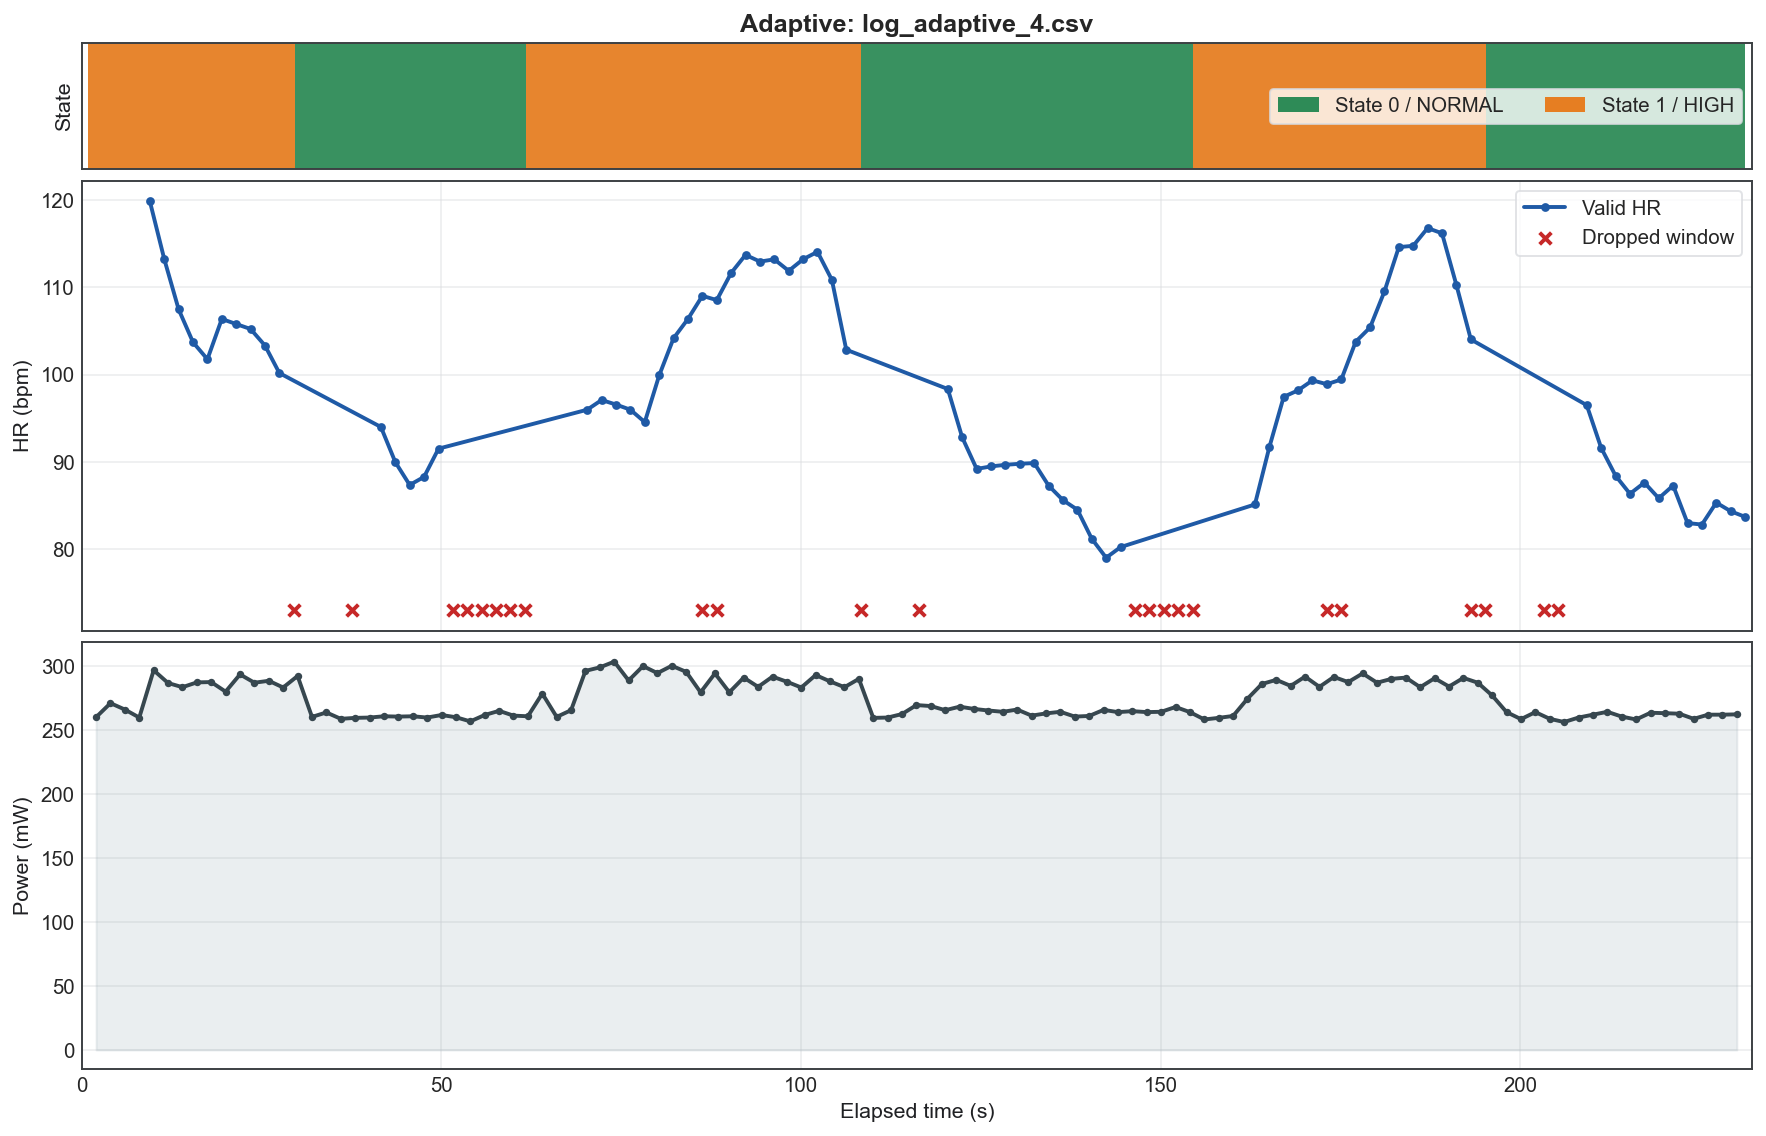

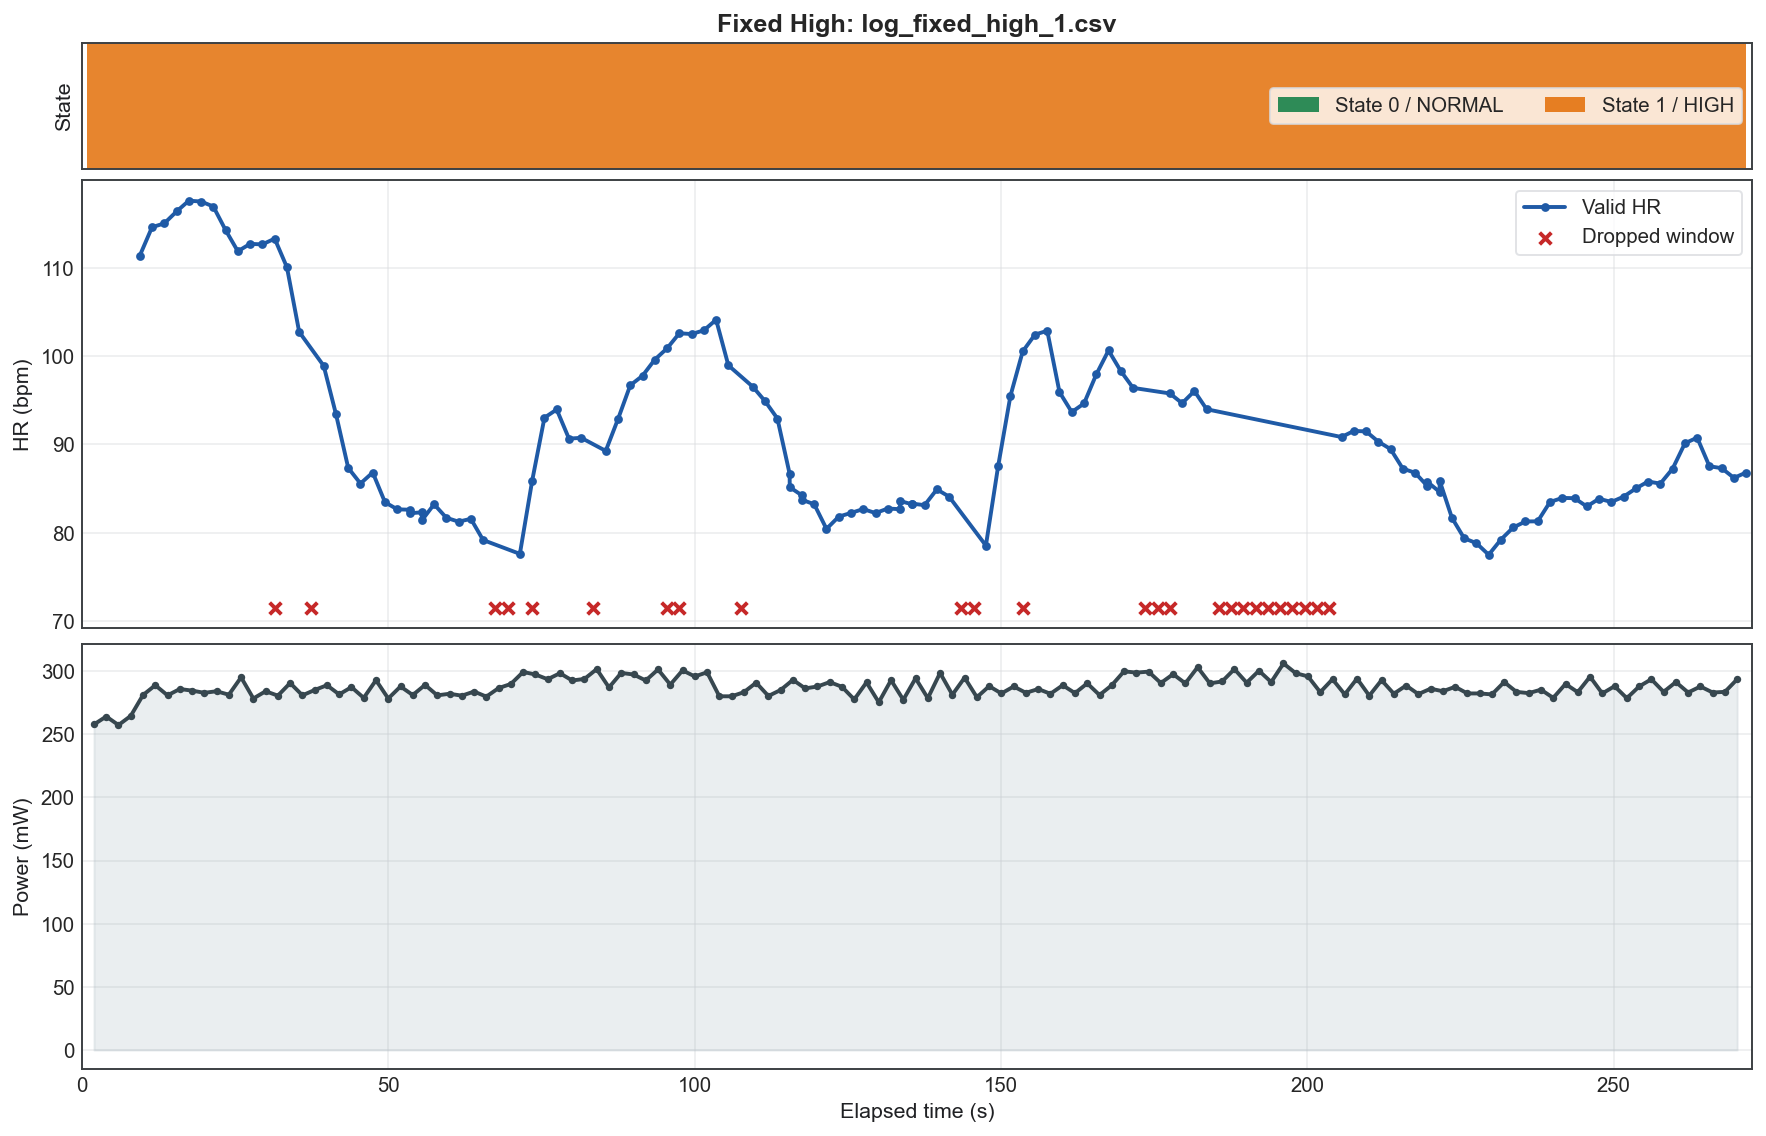

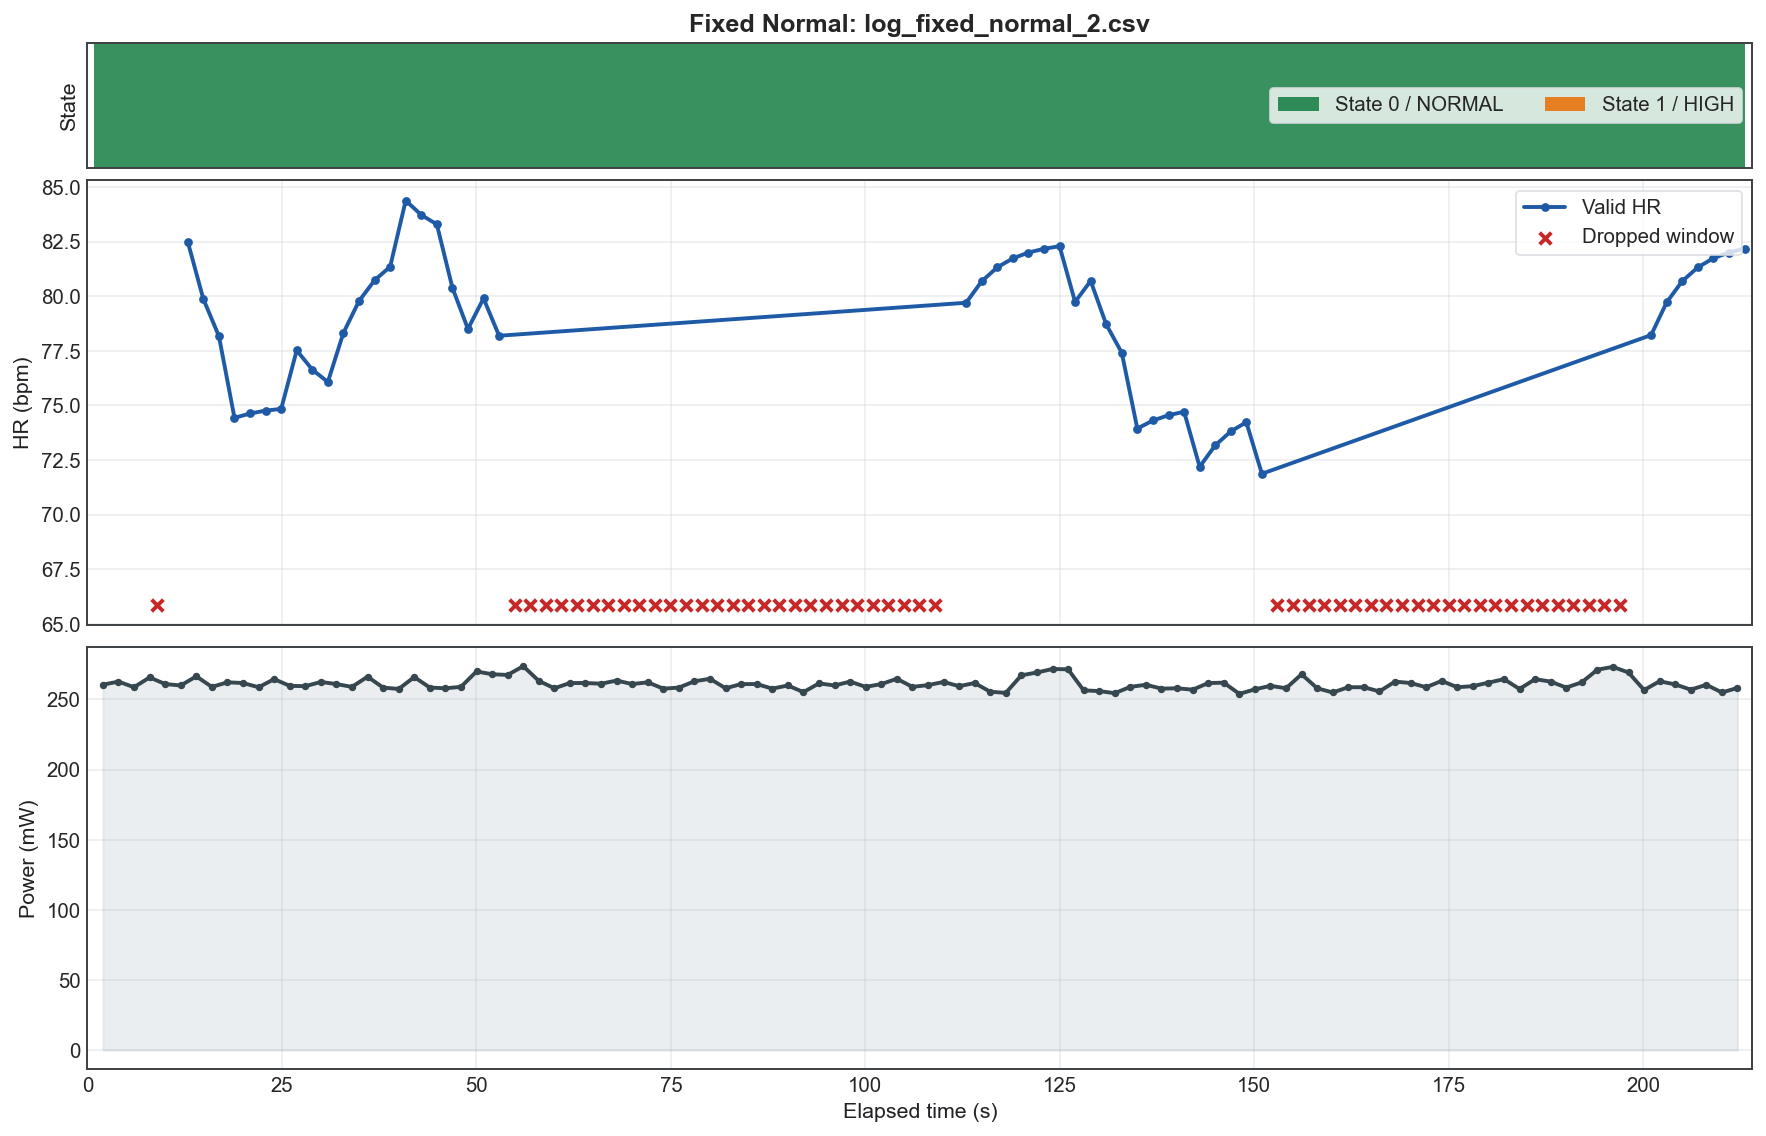

In [10]:
def parse_system_events(log_path: Path) -> pd.DataFrame:
    line_re = re.compile(r"^(?P<level>[IWE]) \((?P<timestamp_ms>\d+)\) PPG_TINYML: (?P<body>.+)$")
    rows = []
    with log_path.open("r", encoding="utf-8", errors="ignore") as handle:
        for raw in handle:
            match = line_re.match(raw.strip())
            if not match:
                continue
            body = match.group("body")
            kind = None
            if "Recovering MAX30102" in body:
                kind = "recover"
            elif "read wr ptr fail" in body or "read rd ptr fail" in body or "read ovf fail" in body:
                kind = "i2c_fail"
            elif "FIFO overflow=" in body:
                kind = "fifo_overflow"
            elif "Low quality window" in body:
                kind = "low_quality"
            elif "NO_CONTACT" in body:
                kind = "no_contact"
            if kind:
                rows.append(
                    {
                        "timestamp_ms": int(match.group("timestamp_ms")),
                        "elapsed_s": int(match.group("timestamp_ms")) / 1000.0,
                        "kind": kind,
                        "body": body,
                    }
                )
    return pd.DataFrame(rows)

def plot_state_timeline(parsed_run: dict[str, object], title: str) -> plt.Figure:
    telemetry_df = parsed_run["telemetry"]
    decision_df = parsed_run["decisions"]
    transition_df = parsed_run["transitions"]
    summary = parsed_run["summary"]

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12.5, 8.0),
        sharex=True,
        gridspec_kw={"height_ratios": [0.28, 1.0, 0.95]},
        constrained_layout=True,
    )
    ax_state, ax_hr, ax_power = axes

    if not transition_df.empty:
        ordered = transition_df.sort_values("timestamp_ms").reset_index(drop=True).copy()
        next_ts = ordered["timestamp_ms"].shift(-1).fillna(int(round(summary["run_duration_s"] * 1000.0)))
        ordered["start_s"] = ordered["timestamp_ms"] / 1000.0
        ordered["end_s"] = next_ts / 1000.0
        for segment in ordered.itertuples(index=False):
            ax_state.axvspan(segment.start_s, segment.end_s, color={0: "#2E8B57", 1: "#E67E22"}.get(int(segment.state), "#B0BEC5"), alpha=0.95, lw=0)

    ax_state.set_ylim(0, 1)
    ax_state.set_yticks([])
    ax_state.set_ylabel("State")
    ax_state.grid(False)
    ax_state.legend(
        handles=[
            Patch(facecolor="#2E8B57", label="State 0 / NORMAL"),
            Patch(facecolor="#E67E22", label="State 1 / HIGH"),
        ],
        loc="center right",
        ncol=2,
    )

    if not decision_df.empty:
        valid_df = decision_df[decision_df["valid_hr"]].copy()
        dropout_df = decision_df[~decision_df["valid_hr"]].copy()
        if not valid_df.empty:
            ax_hr.plot(valid_df["elapsed_s"], valid_df["hr_bpm"], color="#1F5AA6", marker="o", markersize=3.5, label="Valid HR")
        if not dropout_df.empty:
            baseline = float(valid_df["hr_bpm"].min() - 6.0) if not valid_df.empty else 40.0
            ax_hr.scatter(dropout_df["elapsed_s"], np.full(len(dropout_df), baseline), color="#C62828", marker="x", s=36, label="Dropped window")
        ax_hr.set_ylabel("HR (bpm)")
        ax_hr.legend(loc="upper right")

    if not telemetry_df.empty:
        ax_power.plot(telemetry_df["elapsed_s"], telemetry_df["power_mw"], color="#37474F", marker="o", markersize=2.8)
        ax_power.fill_between(telemetry_df["elapsed_s"], telemetry_df["power_mw"], color="#90A4AE", alpha=0.18)
        ax_power.set_ylabel("Power (mW)")

    ax_power.set_xlabel("Elapsed time (s)")
    ax_state.set_title(title)
    max_t = max(180.0, float(summary["run_duration_s"]) + 1.0)
    for ax in axes:
        ax.set_xlim(0, max_t)
    return fig

for mode, file_name in representative_files.items():
    parsed_run = analysis_v6["runs"][(mode, file_name)]
    fig = plot_state_timeline(parsed_run, title=f"{MODE_LABELS[mode]}: {file_name}")
    fig.savefig(OUTPUT_DIR / f"{mode}_{Path(file_name).stem}_timeseries_v6.png", bbox_inches="tight")
    plt.show()


## System Stability Check


In [11]:
stability_rows = []
for mode_dir in sorted(LOG_ROOT.iterdir()):
    if not mode_dir.is_dir():
        continue
    for path in sorted(mode_dir.glob("*.csv")):
        events = parse_system_events(path)
        stability_rows.append(
            {
                "mode": mode_dir.name,
                "file_name": path.name,
                "recover_count": int((events["kind"] == "recover").sum()) if not events.empty else 0,
                "i2c_fail_count": int((events["kind"] == "i2c_fail").sum()) if not events.empty else 0,
                "fifo_overflow_count": int((events["kind"] == "fifo_overflow").sum()) if not events.empty else 0,
            }
        )

stability_df = pd.DataFrame(stability_rows).sort_values(["mode", "file_name"]).reset_index(drop=True)
display(stability_df)
print("Total recover:", int(stability_df["recover_count"].sum()))
print("Total i2c_fail:", int(stability_df["i2c_fail_count"].sum()))
print("Total fifo_overflow:", int(stability_df["fifo_overflow_count"].sum()))


,mode,file_name,recover_count,i2c_fail_count,fifo_overflow_count
0,adaptive,log_adaptive_1.csv,0,0,0
1,adaptive,log_adaptive_2.csv,0,0,0
2,adaptive,log_adaptive_3.csv,0,0,0
3,adaptive,log_adaptive_4.csv,0,0,0
4,fixed_high,log_fixed_high_1.csv,0,0,0
5,fixed_high,log_fixed_high_2.csv,0,0,0
6,fixed_normal,log_fixed_normal_1.csv,0,0,0
7,fixed_normal,log_fixed_normal_2.csv,0,0,0


Total recover: 0
Total i2c_fail: 0
Total fifo_overflow: 0


## Final Interpretation for Thesis

Những điểm chốt có thể dùng trực tiếp trong phần kết quả luận văn:

1. Sau các vòng debug V2-V6, `fixed_normal` và `fixed_high` đã tách power rõ ràng ở mức whole-system.
2. `adaptive/state=0` bám rất sát `fixed_normal`, còn `adaptive/state=1` bám rất sát `fixed_high`.
3. Tỷ lệ sample `adaptive > 300 mW` giảm mạnh từ V5 xuống V6 sau khi đổi sang power-window averaging.
4. `adaptive` giữ coverage cao hơn `fixed_normal` rõ rệt, nhưng vẫn thấp hơn `fixed_high` vì scheduler ưu tiên độ tin cậy thay vì ép output.
5. V6 không còn `Recovering MAX30102`, `I2C fail`, hay `FIFO overflow`, nên kết quả power không còn bị nhiễu bởi lỗi hệ thống như các vòng debug trước.

Kết luận kỹ thuật cuối cùng: V6 cho thấy firmware và wiring hiện tại đã đủ ổn định để dùng làm baseline chính thức cho phần đánh giá macro-level trong báo cáo.
